In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from src.config.spark_session import get_spark_session

spark = get_spark_session()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/23 23:35:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/23 23:35:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [15]:
from pyspark.sql.functions import max, datediff, col
from pyspark.sql import functions as F
from pyspark.sql.functions import col, sum as _sum, countDistinct, datediff, to_date, lit, when, avg, udf, isnan, count

In [17]:

def read_parquet():
    df_cleaned = spark.read.parquet(
        "/Users/yassineoc/Desktop/hamza/Projet_Spark/Customer Segmentation and Churn Prediction with PySpark/data/processed/online_retail_cleaned/*"
    )
    return df_cleaned

df_cleaned= read_parquet()

reference_date = df_cleaned.select(max("InvoiceDate")).first()[0]
df_cleaned.printSchema()
print(reference_date)

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- TotalPrice: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)

2011-12-09 12:50:00


In [26]:
rfm = df_cleaned.groupBy("CustomerID").agg(
    datediff(lit(reference_date), F.max(col("InvoiceDate"))).alias("Recency"),
    countDistinct("InvoiceNo").alias("Frequency"),
    _sum("TotalPrice").alias("Monetary")
)
#rfm.select(max("Recency")).show()

rfm.show(10)

+----------+-------+---------+------------------+
|CustomerID|Recency|Frequency|          Monetary|
+----------+-------+---------+------------------+
|     16503|    106|        5|1421.4299999999998|
|     16339|    284|        1|109.95000000000002|
|     12626|     23|       13| 6388.349999999999|
|     14423|    218|        1|             265.2|
|     17809|     16|       15|           4627.62|
|     13483|     65|        1|140.34000000000003|
|     17754|      0|        6|           1739.92|
|     14837|     89|        5|1641.1999999999998|
|     16283|      5|        7|1531.5099999999993|
|     17783|     72|        2|            283.47|
+----------+-------+---------+------------------+
only showing top 10 rows



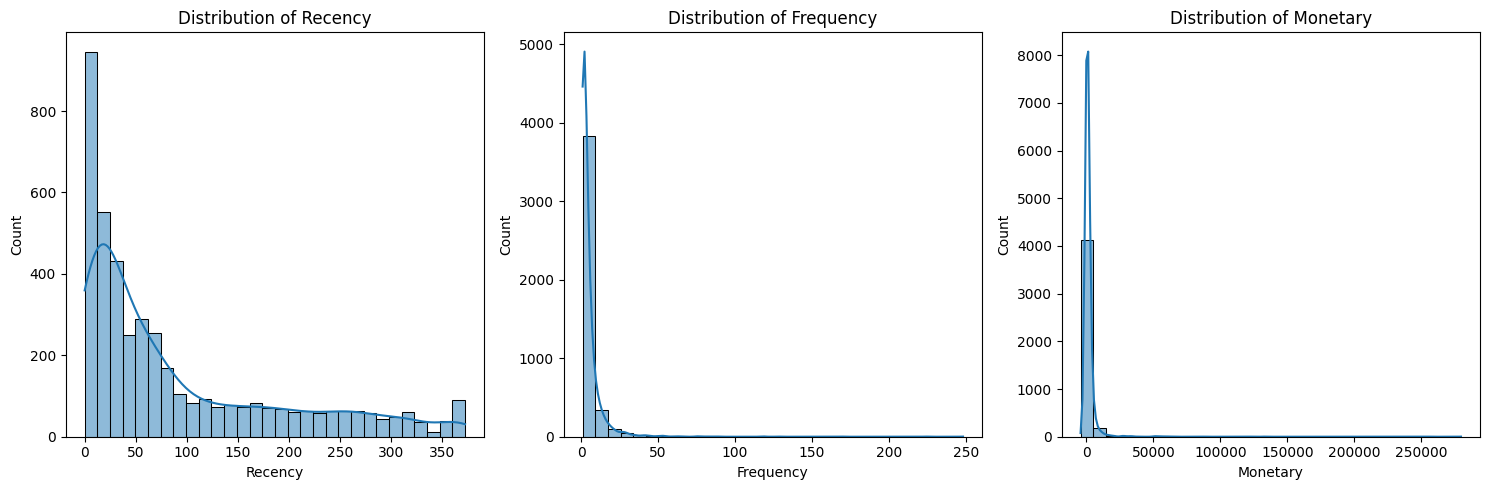

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas for visualization
rfm_pd = rfm.toPandas()

# Distribution plots for RFM metrics
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=rfm_pd, x='Recency', bins=30, kde=True)
plt.title('Distribution of Recency')

plt.subplot(1, 3, 2)
sns.histplot(data=rfm_pd, x='Frequency', bins=30, kde=True)
plt.title('Distribution of Frequency')

plt.subplot(1, 3, 3)
sns.histplot(data=rfm_pd, x='Monetary', bins=30, kde=True)
plt.title('Distribution of Monetary')

plt.tight_layout()
plt.show()

# Interpretation
. Recency : Très skewée droite, majorité clients récents (pic ~0-50 jours), queue longue d'inactifs → beaucoup de clients récents ou one-time.

. Frequency : Fortement skewée, pic élevé à faible fréquence (1-10 achats), très peu de clients fidèles → plupart achètent rarement.

. Monetary : Extrêmement skewée, pic à bas montants, longue queue (quelques gros dépensiers) → valeur client concentrée sur minorité.

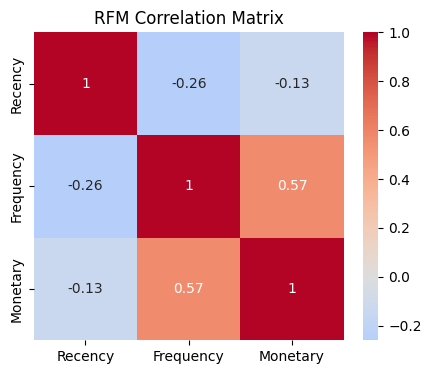

In [22]:
# Correlation matrix
corr_matrix = rfm_pd[['Recency', 'Frequency', 'Monetary']].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('RFM Correlation Matrix')
plt.show()

In [28]:

from pyspark.sql.functions import log

# Apply log transformation to the Frequency and Monetary values
rfm = rfm.withColumn("Log_Frequency", log(rfm["Frequency"] + 1)) \
         .withColumn("Log_Monetary", log(rfm["Monetary"] + 1))

# Calculate RFM score (sum of Recency + Log_Frequency + Log_Monetary)
rfm = rfm.withColumn("RFM_Score", col("Recency") + col("Log_Frequency") + col("Log_Monetary"))

print("Shape of the DataFrame:", (rfm.count(), len(rfm.columns)))
rfm.show(5)

Shape of the DataFrame: (4372, 7)


+----------+-------+---------+------------------+------------------+------------------+------------------+
|CustomerID|Recency|Frequency|          Monetary|     Log_Frequency|      Log_Monetary|         RFM_Score|
+----------+-------+---------+------------------+------------------+------------------+------------------+
|     16503|    106|        5|1421.4299999999998| 1.791759469228055|7.2601219556508365|115.05188142487889|
|     16339|    284|        1|109.95000000000002|0.6931471805599453| 4.709079649378603|289.40222682993857|
|     12626|     23|       13| 6388.349999999999|2.6390573296152584| 8.762387820757855|34.401445150373114|
|     14423|    218|        1|             265.2|0.6931471805599453|5.5842479059610115|224.27739508652095|
|     17809|     16|       15|           4627.62| 2.772588722239781| 8.440014046497208| 27.21260276873699|
+----------+-------+---------+------------------+------------------+------------------+------------------+
only showing top 5 rows



In [29]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Assemble features for clustering
assembler = VectorAssembler(inputCols=["Recency", "Log_Frequency", "Log_Monetary", "RFM_Score"],
                                outputCol="features",
                                handleInvalid="skip")
rfm_features = assembler.transform(rfm)

# Scale the features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
rfm_scaled = scaler.fit(rfm_features).transform(rfm_features)
rfm_scaled.select("scaledFeatures").show(5, truncate=False)

+------------------------------------------------------------------------------+
|scaledFeatures                                                                |
+------------------------------------------------------------------------------+
|[0.1624738296900593,0.4658807952741893,0.5465048767710542,0.17463298451322223]|
|[1.958230099754573,-1.0244350009605365,-1.420833017995309,1.9492720224113338] |
|[-0.6748731951153037,1.6152775373967492,1.705037041123024,-0.646273979013208] |
|[1.292387887258742,-1.0244350009605365,-0.7459121547709234,1.2863936754834298]|
|[-0.7454928237133465,1.7964187332255412,1.456425663404011,-0.719446190390873] |
+------------------------------------------------------------------------------+
only showing top 5 rows



In [30]:
rfm_scaled.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Frequency: long (nullable = false)
 |-- Monetary: double (nullable = true)
 |-- Log_Frequency: double (nullable = true)
 |-- Log_Monetary: double (nullable = true)
 |-- RFM_Score: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)



In [31]:
output_path = "/Users/yassineoc/Desktop/hamza/Projet_Spark/Customer Segmentation and Churn Prediction with PySpark/data/processed/rfm_scaled"

rfm_scaled.write.mode("overwrite").parquet(output_path)